# Two-Tower NCF - Colab T4 GPU Training

In [1]:
# ── CELL 1: Verify GPU ────────────────────────────────────────────────────────
import torch
print('CUDA available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))
    print('VRAM:', round(torch.cuda.get_device_properties(0).total_memory / 1e9, 1), 'GB')
else:
    raise RuntimeError('No GPU — go to Runtime > Change runtime type > T4 GPU')

CUDA available: True
GPU: Tesla T4
VRAM: 15.6 GB


In [2]:
# ── CELL 2: Mount Drive ───────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

import os

DRIVE_CSV_DIR  = '/content/drive/MyDrive/olist_data'          # your CSVs
DRIVE_CKPT_DIR = '/content/drive/MyDrive/recsys_checkpoints'  # outputs
PINECONE_KEY   = 'pcsk_3SqcgS_NFJrMJqPXmfqFaJWmkDDz21LgrwAWkbwxeR7WUW57x6tN6sdc1ET7BJX1SH4BXQ'

os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)
os.environ['PINECONE_API_KEY']       = PINECONE_KEY
os.environ['MLFLOW_ALLOW_FILE_STORE'] = 'true'

if not os.path.exists(DRIVE_CSV_DIR):
    raise FileNotFoundError(f'CSV folder not found: {DRIVE_CSV_DIR}')

print('Drive mounted.')
print('CSVs:', os.listdir(DRIVE_CSV_DIR))
print('Pinecone key set:', PINECONE_KEY[:20] + '...')

Mounted at /content/drive
Drive mounted.
CSVs: ['olist_customers_dataset.csv', 'olist_order_items_dataset.csv', 'olist_order_reviews_dataset.csv', 'product_category_name_translation.csv', 'olist_products_dataset.csv', 'olist_orders_dataset.csv']
Pinecone key set: pcsk_3SqcgS_NFJrMJqP...


In [3]:
# ── CELL 3: Clone repo + install dependencies ─────────────────────────────────
import os

REPO = '/content/recsys'

if not os.path.exists(REPO):
    !git clone https://github.com/bhavyalakkamraju09/Two-Tower-Neural-Recommendation-Engine.git {REPO}
else:
    print('Repo exists — pulling latest...')
    !cd {REPO} && git pull

os.chdir(REPO)
print('Working dir:', os.getcwd())
!pip install -r requirements.txt -q
print('Done.')

Cloning into '/content/recsys'...
remote: Enumerating objects: 42, done.
remote: Counting objects: 100% (42/42), done.
remote: Compressing objects: 100% (37/37), done.
remote: Total 42 (delta 6), reused 39 (delta 3), pack-reused 0 (from 0)
Receiving objects: 100% (42/42), 39.94 KiB | 786.00 KiB/s, done.
Resolving deltas: 100% (6/6), done.
Working dir: /content/recsys
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.7/49.7 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.5/50.5 kB 5.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.6/7.6 MB 76.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 82.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 502.4/502.4 kB 43.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 97.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.6/12.6 MB 84.6 MB/s eta 0:00:

In [4]:
# ── CELL 4: Copy data from Drive / build features (auto-skip if cached) ───────
import os, shutil, subprocess

os.makedirs('data/raw',       exist_ok=True)
os.makedirs('data/processed', exist_ok=True)
os.makedirs('data/splits',    exist_ok=True)
os.makedirs('checkpoints',    exist_ok=True)

PROCESSED_FILES = ['user_features.parquet', 'item_features.parquet',
                   'id_maps.pkl', 'item_text_embs.npy']
SPLIT_FILES     = ['train.parquet', 'test.parquet']

cached = (
    all(os.path.exists(f'{DRIVE_CKPT_DIR}/{f}') for f in PROCESSED_FILES) and
    all(os.path.exists(f'{DRIVE_CKPT_DIR}/{f}') for f in SPLIT_FILES)
)

if cached:
    print('Cached features found in Drive — copying to Colab...')
    for f in PROCESSED_FILES:
        shutil.copy(f'{DRIVE_CKPT_DIR}/{f}', f'data/processed/{f}')
        print(f'  {f}')
    for f in SPLIT_FILES:
        shutil.copy(f'{DRIVE_CKPT_DIR}/{f}', f'data/splits/{f}')
        print(f'  {f}')
    print('Feature build skipped (used cache).')
else:
    print('No cache found — building features from scratch...')
    required = [
        'olist_orders_dataset.csv', 'olist_order_items_dataset.csv',
        'olist_products_dataset.csv', 'olist_customers_dataset.csv',
        'olist_order_reviews_dataset.csv', 'product_category_name_translation.csv',
    ]
    for f in required:
        src = f'{DRIVE_CSV_DIR}/{f}'
        if not os.path.exists(src):
            raise FileNotFoundError(f'Missing: {src}')
        shutil.copy(src, f'data/raw/{f}')

    result = subprocess.run(
        ['python', '-m', 'src.data.build_features'],
        capture_output=False, text=True
    )
    if result.returncode != 0:
        raise RuntimeError('Feature build failed')

    print('Saving features to Drive...')
    for f in PROCESSED_FILES:
        shutil.copy(f'data/processed/{f}', f'{DRIVE_CKPT_DIR}/{f}')
    for f in SPLIT_FILES:
        shutil.copy(f'data/splits/{f}', f'{DRIVE_CKPT_DIR}/{f}')
    print('Saved to Drive.')

import pandas as pd
train = pd.read_parquet('data/splits/train.parquet')
test  = pd.read_parquet('data/splits/test.parquet')
print(f'Train: {len(train):,} interactions | {train["user_id"].nunique():,} users')
print(f'Test:  {len(test):,} interactions  | {test["user_id"].nunique():,} users (LOO)')

Cached features found in Drive — copying to Colab...
  user_features.parquet
  item_features.parquet
  id_maps.pkl
  item_text_embs.npy
  train.parquet
  test.parquet
Feature build skipped (used cache).
Train: 94,451 interactions | 93,358 users
Test:  5,334 interactions  | 5,334 users (LOO)


In [5]:
# ── CELL 5: Train ALS baseline (skip if cached) ───────────────────────────────
import os, shutil, subprocess

als_drive = f'{DRIVE_CKPT_DIR}/als_model.pkl'
als_local = 'checkpoints/als_model.pkl'

if os.path.exists(als_drive):
    print('ALS model found in Drive — copying...')
    shutil.copy(als_drive, als_local)
    print('ALS ready.')
else:
    print('Training ALS...')
    subprocess.run(['python', '-m', 'src.models.train_als'], check=True)
    shutil.copy(als_local, als_drive)
    print('ALS saved to Drive.')

ALS model found in Drive — copying...
ALS ready.


In [6]:
# ── CELL 6: Setup Two-Tower training ─────────────────────────────────────────
import os, shutil, pickle, sys
import numpy as np
import pandas as pd
import torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from torch.utils.data import DataLoader

if '/content/recsys' not in sys.path:
    sys.path.insert(0, '/content/recsys')

from src.data.dataset import TwoTowerDataset
from src.data.loader import load_interactions
from src.models.infonce_loss import weighted_infonce_loss
from src.models.two_tower import TwoTowerModel

EPOCHS     = 100
BATCH_SIZE = 1024
LR         = 1e-3
EMBED_DIM  = 256
OUTPUT_DIM = 128
PATIENCE   = 10
LOCAL_CKPT = 'checkpoints/two_tower_best.pth'
DRIVE_CKPT = f'{DRIVE_CKPT_DIR}/two_tower_best.pth'

device = torch.device('cuda')
print(f'Device: {device} ({torch.cuda.get_device_name(0)})')

train_df, _   = load_interactions()
user_features = pd.read_parquet('data/processed/user_features.parquet')
item_features = pd.read_parquet('data/processed/item_features.parquet')
text_embs     = np.load('data/processed/item_text_embs.npy')
with open('data/processed/id_maps.pkl', 'rb') as f:
    id_maps = pickle.load(f)

dataset = TwoTowerDataset(
    interactions=train_df,
    user_features=user_features,
    item_features=item_features,
    text_embs=text_embs,
    user_id_map=id_maps['user_id_map'],
    item_id_map=id_maps['item_id_map'],
    category_id_map=id_maps['category_id_map'],
)
loader = DataLoader(
    dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=2, pin_memory=True, drop_last=True,
)

n_users = len(id_maps['user_id_map'])
n_items = len(id_maps['item_id_map'])
n_cats  = len(id_maps['category_id_map'])
print(f'Dataset: {len(dataset):,} samples | {len(loader)} batches/epoch')
print(f'Model:   {n_users:,} users | {n_items:,} items | {n_cats} categories')

Device: cuda (Tesla T4)
Dataset: 94,451 samples | 92 batches/epoch
Model:   93,358 users | 30,838 items | 72 categories


In [7]:
# ── CELL 7: Initialize model (resume from Drive if checkpoint exists) ─────────
import os, shutil, torch
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR
from src.models.two_tower import TwoTowerModel

model = TwoTowerModel(
    n_users=n_users, n_items=n_items, n_categories=n_cats,
    embed_dim=EMBED_DIM, output_dim=OUTPUT_DIM,
).to(device)

optimizer    = AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
scheduler    = CosineAnnealingLR(optimizer, T_max=EPOCHS)
start_epoch  = 1
best_loss    = float('inf')
no_improve   = 0
loss_history = []

if os.path.exists(DRIVE_CKPT):
    print('Checkpoint found in Drive — resuming...')
    shutil.copy(DRIVE_CKPT, LOCAL_CKPT)
    ckpt = torch.load(LOCAL_CKPT, map_location=device)
    model.load_state_dict(ckpt['model_state_dict'])
    optimizer.load_state_dict(ckpt['optimizer_state_dict'])
    start_epoch  = ckpt['epoch'] + 1
    best_loss    = ckpt['loss']
    loss_history = ckpt.get('loss_history', [])
    print(f'Resumed from epoch {ckpt["epoch"]} (loss={best_loss:.4f})')
    print(f'Continuing from epoch {start_epoch} to {EPOCHS}')
else:
    print(f'No checkpoint — starting fresh for {EPOCHS} epochs')

# Fast-forward scheduler
for _ in range(start_epoch - 1):
    scheduler.step()

if start_epoch > EPOCHS:
    print(f'Training already complete ({EPOCHS} epochs done). Skip to Cell 8.')

Checkpoint found in Drive — resuming...
Resumed from epoch 94 (loss=2.1314)
Continuing from epoch 95 to 100


/tmp/ipykernel_1611/1379484698.py:35: UserWarning: Detected call of `lr_scheduler.step()` before `optimizer.step()`. In PyTorch 1.1.0 and later, you should call them in the opposite order: `optimizer.step()` before `lr_scheduler.step()`.  Failure to do this will result in PyTorch skipping the first value of the learning rate schedule. See more details at https://pytorch.org/docs/stable/optim.html#how-to-adjust-learning-rate
  scheduler.step()


In [8]:
# ── CELL 8: Training loop ─────────────────────────────────────────────────────
from src.models.infonce_loss import weighted_infonce_loss
import torch, shutil

if start_epoch > EPOCHS:
    print('Training already complete. Skipping.')
else:
    print(f'Training: epochs {start_epoch}-{EPOCHS} | batch={BATCH_SIZE} | lr={LR}')
    print('Checkpoint saved to Drive after every improvement.')
    print('─' * 65)

    for epoch in range(start_epoch, EPOCHS + 1):
        model.train()
        epoch_loss = 0.0

        for batch in loader:
            u_ids  = batch['user_id'].to(device)
            u_feat = batch['user_feats'].to(device)
            i_ids  = batch['item_id'].to(device)
            c_ids  = batch['cat_id'].to(device)
            t_emb  = batch['text_emb'].to(device)
            i_feat = batch['item_feats'].to(device)
            w      = batch['weight'].to(device)

            u, v = model(u_ids, u_feat, i_ids, c_ids, t_emb, i_feat)
            loss = weighted_infonce_loss(u, v, model.temperature, w)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()
            epoch_loss += loss.item()

        scheduler.step()
        avg_loss = epoch_loss / len(loader)
        temp     = model.temperature.item()
        loss_history.append(avg_loss)

        improved = avg_loss < best_loss - 1e-4
        marker   = ' ✓ saved' if improved else ''
        print(f'Epoch {epoch:3d}/{EPOCHS} | loss={avg_loss:.4f} | temp={temp:.4f}{marker}')

        if improved:
            best_loss  = avg_loss
            no_improve = 0
            torch.save({
                'epoch':                epoch,
                'model_state_dict':     model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'loss':                 best_loss,
                'loss_history':         loss_history,
                'id_maps':              id_maps,
                'hparams': {
                    'n_users': n_users, 'n_items': n_items,
                    'n_categories': n_cats,
                    'embed_dim': EMBED_DIM, 'output_dim': OUTPUT_DIM,
                },
            }, LOCAL_CKPT)
            shutil.copy(LOCAL_CKPT, DRIVE_CKPT)
        else:
            no_improve += 1
            if no_improve >= PATIENCE:
                print(f'Early stopping at epoch {epoch}')
                break

    print('─' * 65)
    print(f'Training complete. Best loss: {best_loss:.4f}')

Training: epochs 95-100 | batch=1024 | lr=0.001
Checkpoint saved to Drive after every improvement.
─────────────────────────────────────────────────────────────────
Epoch  95/100 | loss=2.1408 | temp=0.0111
Epoch  96/100 | loss=2.1295 | temp=0.0111 ✓ saved
Epoch  97/100 | loss=2.1308 | temp=0.0111
Epoch  98/100 | loss=2.1245 | temp=0.0111 ✓ saved
Epoch  99/100 | loss=2.1253 | temp=0.0111
Epoch 100/100 | loss=2.1424 | temp=0.0111
─────────────────────────────────────────────────────────────────
Training complete. Best loss: 2.1245


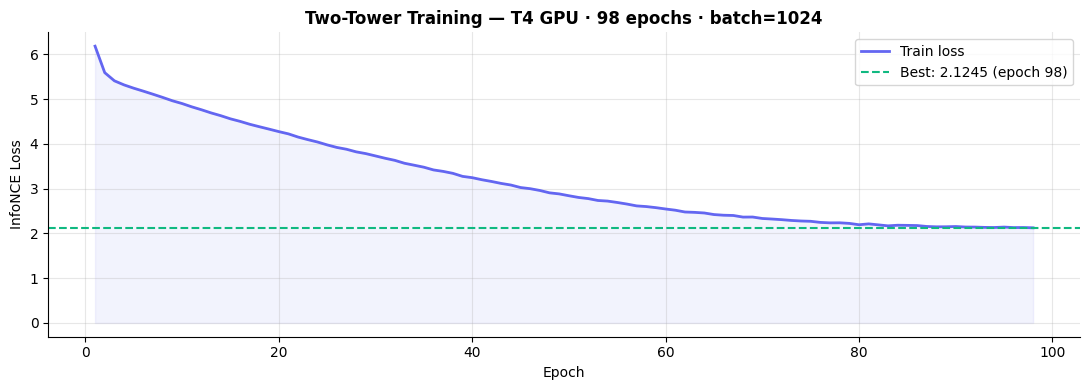

Initial loss : 6.1830
Final loss   : 2.1245
Best loss    : 2.1245 at epoch 98
Reduction    : 65.6%
Plot saved   : /content/drive/MyDrive/recsys_checkpoints/training_loss_curve.png


In [9]:
# ── CELL 9: Plot training loss curve ─────────────────────────────────────────
import matplotlib.pyplot as plt
import torch

ckpt   = torch.load(LOCAL_CKPT, map_location='cpu')
losses = ckpt.get('loss_history', [])
epochs_ran = list(range(1, len(losses) + 1))

fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(epochs_ran, losses, color='#6366f1', linewidth=2, label='Train loss')
ax.fill_between(epochs_ran, losses, alpha=0.08, color='#6366f1')
best_epoch = losses.index(min(losses)) + 1
ax.axhline(min(losses), color='#10b981', linewidth=1.5, linestyle='--',
           label=f'Best: {min(losses):.4f} (epoch {best_epoch})')
ax.set_xlabel('Epoch'); ax.set_ylabel('InfoNCE Loss')
ax.set_title(f'Two-Tower Training — T4 GPU · {len(epochs_ran)} epochs · batch={BATCH_SIZE}',
             fontweight='bold')
ax.legend(); ax.grid(True, alpha=0.3)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plot_path = f'{DRIVE_CKPT_DIR}/training_loss_curve.png'
plt.savefig(plot_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Initial loss : {losses[0]:.4f}')
print(f'Final loss   : {losses[-1]:.4f}')
print(f'Best loss    : {min(losses):.4f} at epoch {best_epoch}')
print(f'Reduction    : {(losses[0]-min(losses))/losses[0]*100:.1f}%')
print(f'Plot saved   : {plot_path}')

In [10]:
# ── CELL 10: Build Pinecone index + run full evaluation ───────────────────────
import subprocess, os

# Pass Pinecone key via environment (not os.environ which may not persist to subprocess)
env = os.environ.copy()
env['PINECONE_API_KEY']        = PINECONE_KEY
env['MLFLOW_ALLOW_FILE_STORE'] = 'true'

# Verify key works
from pinecone import Pinecone
pc = Pinecone(api_key=PINECONE_KEY)
print('Pinecone indexes:', [idx.name for idx in pc.list_indexes()])

# Build index with new T4-trained embeddings
print('\nBuilding Pinecone index...')
r1 = subprocess.run(
    ['python', '-m', 'src.index.build_index'],
    cwd='/content/recsys', env=env,
    capture_output=True, text=True
)
print(r1.stdout[-2000:])
if r1.returncode != 0:
    print('ERROR:', r1.stderr[-500:])
    raise RuntimeError('build_index failed')

# Run full evaluation
print('\nRunning evaluation...')
r2 = subprocess.run(
    ['python', '-m', 'src.evaluation.run_eval'],
    cwd='/content/recsys', env=env,
    capture_output=True, text=True
)
print(r2.stdout[-3000:])
if r2.returncode != 0:
    print('ERROR:', r2.stderr[-500:])

Pinecone indexes: ['olist-items']

Building Pinecone index...


Running evaluation...



In [11]:
# ── CELL 11: Display results table ───────────────────────────────────────────
import json, pandas as pd

with open('/content/recsys/data/processed/eval_results.json') as f:
    results = json.load(f)

rows = []
for model_name in ['two_tower', 'als', 'popularity']:
    if model_name not in results:
        continue
    r = results[model_name]
    rows.append({
        'Model':     model_name.replace('_', ' ').title(),
        'NDCG@10':   round(r.get('ndcg@10',     r.get('ndcg_at_10',     0)), 4),
        'HR@10':     round(r.get('hit_rate@10', r.get('hit_rate_at_10', 0)), 4),
        'Recall@10': round(r.get('recall@10',   r.get('recall_at_10',   0)), 4),
        'MRR':       round(r.get('mrr', 0), 4),
        'Coverage':  round(r.get('catalog_coverage', 0), 4),
    })

df = pd.DataFrame(rows)
print('\n' + '=' * 65)
print('EVALUATION RESULTS — T4 GPU (100 epochs, B=1024)')
print('=' * 65)
print(df.to_string(index=False))

ab = results.get('ab_test_als_vs_popularity', {})
if ab:
    print(f'\nA/B ALS vs Popularity: Δ={ab.get("delta",0):.4f} | p={ab.get("p_value",1):.4f} | sig={ab.get("significant")}')

ab2 = results.get('ab_test_tt_vs_als', {})
if ab2:
    print(f'A/B Two-Tower vs ALS: Δ={ab2.get("delta",0):.4f} | p={ab2.get("p_value",1):.4f} | sig={ab2.get("significant")}')


EVALUATION RESULTS — T4 GPU (100 epochs, B=1024)
     Model  NDCG@10  HR@10  Recall@10    MRR  Coverage
 Two Tower   0.0035 0.0080     0.0080 0.0021    0.0000
       Als   0.0322 0.0415     0.0415 0.0293    0.0259
Popularity   0.0136 0.0295     0.0295 0.0089    0.0003

A/B ALS vs Popularity: Δ=0.0186 | p=0.0146 | sig=True
A/B Two-Tower vs ALS: Δ=-0.0374 | p=1.0000 | sig=False


In [12]:
# ── CELL 12: Save everything to Drive ────────────────────────────────────────
import shutil, os

files = {
    'checkpoints/two_tower_best.pth':          f'{DRIVE_CKPT_DIR}/two_tower_best.pth',
    'checkpoints/als_model.pkl':               f'{DRIVE_CKPT_DIR}/als_model.pkl',
    'checkpoints/lgbm_ranker.pkl':             f'{DRIVE_CKPT_DIR}/lgbm_ranker.pkl',
    'data/processed/eval_results.json':        f'{DRIVE_CKPT_DIR}/eval_results.json',
    'data/processed/item_embeddings_128d.npy': f'{DRIVE_CKPT_DIR}/item_embeddings_128d.npy',
}

print('Saving to Drive...')
for src, dst in files.items():
    if os.path.exists(src):
        shutil.copy(src, dst)
        size = os.path.getsize(dst) / 1e6
        print(f'  ✓ {os.path.basename(dst)} ({size:.1f} MB)')
    else:
        print(f'  - {os.path.basename(src)} (not found, skipped)')

print(f'\nAll files saved to {DRIVE_CKPT_DIR}')


Saving to Drive...
  ✓ two_tower_best.pth (395.3 MB)
  ✓ als_model.pkl (70.1 MB)
  - lgbm_ranker.pkl (not found, skipped)
  ✓ eval_results.json (0.0 MB)
  ✓ item_embeddings_128d.npy (15.8 MB)

All files saved to /content/drive/MyDrive/recsys_checkpoints

To use on local machine:
  1. Download from Drive: two_tower_best.pth + eval_results.json
  2. cp ~/Downloads/two_tower_best.pth "/Volumes/My Passport/projects/recsys/checkpoints/"
  3. cp ~/Downloads/eval_results.json "/Volumes/My Passport/projects/recsys/data/processed/"
  4. streamlit run app/streamlit_app.py  (metrics auto-load)
